In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create dataset
data = {
    'Student_ID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['A','B','C','D','E','F','G','H','I','J'],
    'Maths': [85, 90, np.nan, 45, 78, 200, 88, 76, 95, 89],
    'Science': [80, np.nan, 70, 60, 75, 85, 90, 120, 88, 92],
    'English': [78, 85, 88, np.nan, 70, 95, 100, 65, 80, 82],
    'Attendance (%)': [90, 85, 88, 92, np.nan, 95, 110, 80, 87, 89]
}

df = pd.DataFrame(data)
df

,Student_ID,Name,Maths,Science,English,Attendance (%)
0,1,A,85.0,80.0,78.0,90.0
1,2,B,90.0,NaN,85.0,85.0
2,3,C,NaN,70.0,88.0,88.0
3,4,D,45.0,60.0,NaN,92.0
4,5,E,78.0,75.0,70.0,NaN
5,6,F,200.0,85.0,95.0,95.0
6,7,G,88.0,90.0,100.0,110.0
7,8,H,76.0,120.0,65.0,80.0
8,9,I,95.0,88.0,80.0,87.0
9,10,J,89.0,92.0,82.0,89.0


In [3]:
df.isnull().sum()

Student_ID        0
Name              0
Maths             1
Science           1
English           1
Attendance (%)    1
dtype: int64

In [4]:
# Fill missing numeric values with mean
df['Maths'] = df['Maths'].fillna(df['Maths'].mean())
df['Science'] = df['Science'].fillna(df['Science'].mean())
df['English'] = df['English'].fillna(df['English'].mean())
df['Attendance (%)'] = df['Attendance (%)'].fillna(df['Attendance (%)'].mean())

In [5]:
# Cap attendance at 100%
df['Attendance (%)'] = np.where(df['Attendance (%)'] > 100, 100, df['Attendance (%)'])

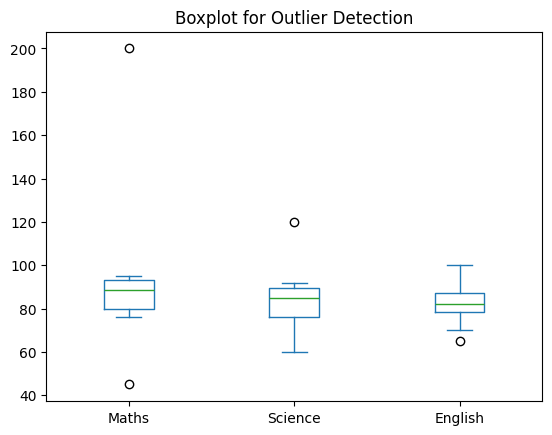

In [6]:
df[['Maths','Science','English']].plot(kind='box')
plt.title("Boxplot for Outlier Detection")
plt.show()

In [7]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return np.where(df[col] > upper, upper,
           np.where(df[col] < lower, lower, df[col]))

# Apply on columns
df['Maths'] = remove_outliers('Maths')
df['Science'] = remove_outliers('Science')
df['English'] = remove_outliers('English')

In [8]:
df['Maths_log'] = np.log(df['Maths'])
df['Science_log'] = np.log(df['Science'])

In [9]:
df[['Maths','Maths_log']].head()

,Maths,Maths_log
0,85.000,4.442651
1,90.000,4.499810
2,94.000,4.543295
3,59.875,4.092259
4,78.000,4.356709


In [10]:
df 

,Student_ID,Name,Maths,Science,English,Attendance (%),Maths_log,Science_log
0,1,A,85.000,80.000000,78.000000,90.000000,4.442651,4.382027
1,2,B,90.000,84.444444,85.000000,85.000000,4.499810,4.436094
2,3,C,94.000,70.000000,88.000000,88.000000,4.543295,4.248495
3,4,D,59.875,60.000000,82.555556,92.000000,4.092259,4.094345
4,5,E,78.000,75.000000,70.000000,90.666667,4.356709,4.317488
5,6,F,112.875,85.000000,95.000000,95.000000,4.726281,4.442651
6,7,G,88.000,90.000000,100.000000,100.000000,4.477337,4.499810
7,8,H,76.000,109.375000,65.375000,80.000000,4.330733,4.694782
8,9,I,95.000,88.000000,80.000000,87.000000,4.553877,4.477337
9,10,J,89.000,92.000000,82.000000,89.000000,4.488636,4.521789
